In [1]:
# IMPORT LIBRARIES
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# LOAD DATA
df = pd.read_csv(r"C:\Users\User\Downloads\advertising.csv") 
# If the CSV has an index column (e.g., "Unnamed: 0"), you can drop it:
# df = df.drop(columns=['Unnamed: 0'])

# INSPECT DATA
print("Shape of dataset:", df.shape)
print(df.head())

# DEFINE FEATURES AND TARGET
X = df[['TV', 'Radio', 'Newspaper']]  # predictors
y = df['Sales']                      # target

# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CREATE MODEL
reg_model = LinearRegression()

# TRAIN MODEL
reg_model.fit(X_train, y_train)

# PREDICT
y_pred = reg_model.predict(X_test)

# MODEL COEFFICIENTS
print("Intercept:", reg_model.intercept_)
print("Coefficients:")
for feature, coef in zip(X.columns, reg_model.coef_):
    print(f"  {feature}: {coef:.4f}")

# EVALUATION
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R^2): {r2:.4f}")

# OPTIONAL: Display predictions vs actual
results = pd.DataFrame({'Actual Sales': y_test, 'Predicted Sales': y_pred})
print(results.head())


Shape of dataset: (200, 4)
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
Intercept: 4.714126402214127
Coefficients:
  TV: 0.0545
  Radio: 0.1009
  Newspaper: 0.0043
Mean Squared Error (MSE): 2.9078
R-squared (R^2): 0.9059
     Actual Sales  Predicted Sales
95           16.9        17.034772
15           22.4        20.409740
30           21.4        23.723989
158           7.3         9.272785
128          24.7        21.682719


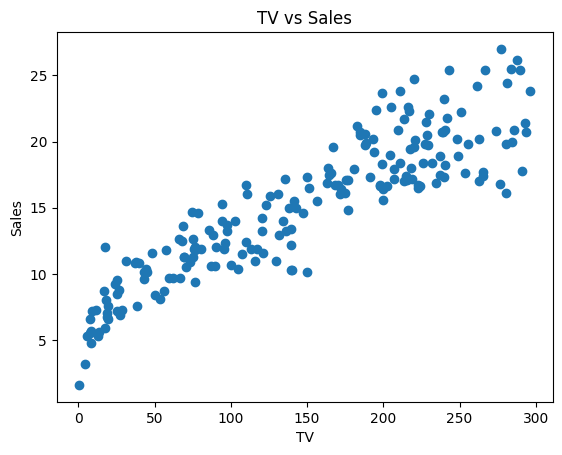

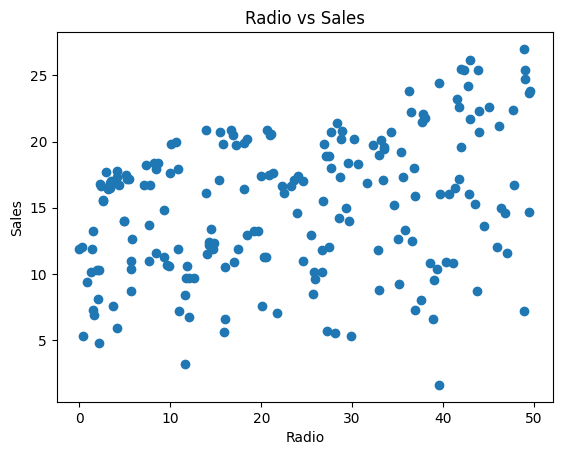

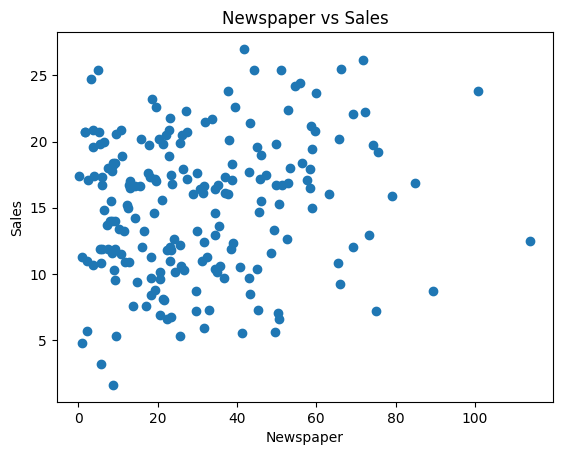

In [2]:
import matplotlib.pyplot as plt

features = ['TV', 'Radio', 'Newspaper']

for feature in features:
    plt.figure()
    plt.scatter(df[feature], df['Sales'])
    plt.xlabel(feature)
    plt.ylabel('Sales')
    plt.title(f'{feature} vs Sales')
    plt.show()

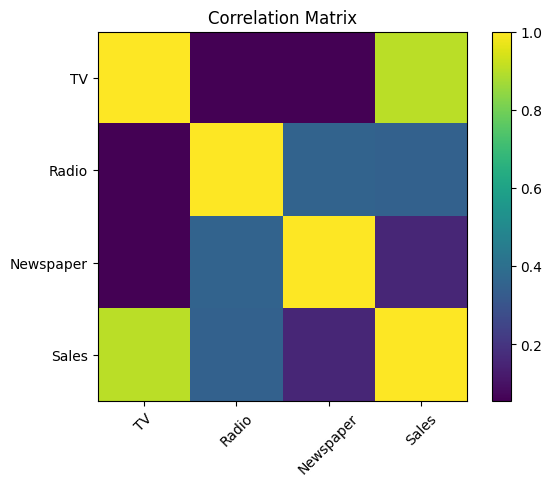

In [3]:
import numpy as np

corr = df.corr()

plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()
